In [1]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

# Import from the engine
from l_vqe_engine import (
    build_maxcut_hamiltonian,
    best_known_maxcut_cost,
    simulate_one_lvqe
)

=== 1. MAX-CUT GRAPH SETUP & BASELINE ===


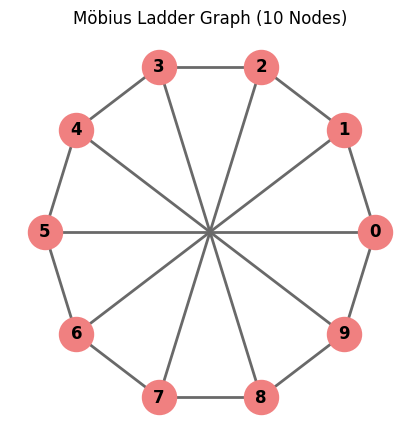

Calculating exact classical baseline...
True Maximum Cut (Negative Cost): -15.00
Total Qubits Required: 10


In [2]:
print("=== 1. MAX-CUT GRAPH SETUP & BASELINE ===")

def generate_mobius_ladder(n_nodes):
    """Generates a Möbius Ladder graph of n_nodes (must be even)."""
    assert n_nodes % 2 == 0, "Möbius ladder requires an even number of nodes."
    # Start with a standard ring (cycle graph)
    G = nx.cycle_graph(n_nodes)
    # Add the "rungs" across the opposite sides of the circle
    half = n_nodes // 2
    for i in range(half):
        G.add_edge(i, i + half)
    return G

# Generate the 10-node Möbius Ladder
n_nodes = 10
G_maxcut = generate_mobius_ladder(n_nodes)

# Visualize it
plt.figure(figsize=(4, 4))
pos = nx.circular_layout(G_maxcut) # Circular layout shows the cross-rungs beautifully
nx.draw(
    G_maxcut, 
    pos, 
    with_labels=True, 
    node_color='lightcoral', 
    edge_color='dimgray',
    width=2.0,
    font_weight='bold',
    node_size=600
)
plt.title(f"Möbius Ladder Graph ({n_nodes} Nodes)")
plt.show()

# Calculate absolute true baseline
print("Calculating exact classical baseline...")
true_maxcut_val = best_known_maxcut_cost(G_maxcut)
print(f"True Maximum Cut (Negative Cost): {true_maxcut_val:.2f}")
print(f"Total Qubits Required: {n_nodes}")

In [5]:
print("\n=== 2. L-VQE EXECUTION (SMO MAX-CUT) ===")

H_mc = build_maxcut_hamiltonian(G_maxcut)
rng_mc = np.random.default_rng(101)

# Run SMO
smo_res = simulate_one_lvqe(
    n_q=n_nodes,
    H=H_mc,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_mc,
    optimizer="SMO"
)

rho_smo = smo_res['final_cost'] / true_maxcut_val

print(f"\nSMO Final Cost: {smo_res['final_cost']:.4f}")
print(f"SMO Approximation Ratio (ρ): {rho_smo:.4f}")


=== 2. L-VQE EXECUTION (SMO MAX-CUT) ===
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -15.000000
  Layer 2  (82 params) ... cost = -15.000000

SMO Final Cost: -15.0000
SMO Approximation Ratio (ρ): 1.0000


In [12]:
print("\n=== 2. L-VQE EXECUTION (COBYLA MAX-CUT) ===")

H_mc = build_maxcut_hamiltonian(G_maxcut)
rng_mc = np.random.default_rng(101)

# Run SMO
cobyla_res = simulate_one_lvqe(
    n_q=n_nodes,
    H=H_mc,
    max_layers=2,
    shots=None,
    max_iter_per_layer=600,
    rng=rng_mc,
    optimizer="COBYLA"
)

rho_cobyla = cobyla_res['final_cost'] / true_maxcut_val

print(f"\nCOBYLA Final Cost: {cobyla_res['final_cost']:.4f}")
print(f"COBYLA Approximation Ratio (ρ): {rho_cobyla:.4f}")


=== 2. L-VQE EXECUTION (COBYLA MAX-CUT) ===
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -15.000000
  Layer 2  (82 params) ... cost = -15.000000

COBYLA Final Cost: -15.0000
COBYLA Approximation Ratio (ρ): 1.0000



=== 3. OPTIMIZER TRAJECTORY COMPARISON (MAX-CUT) ===


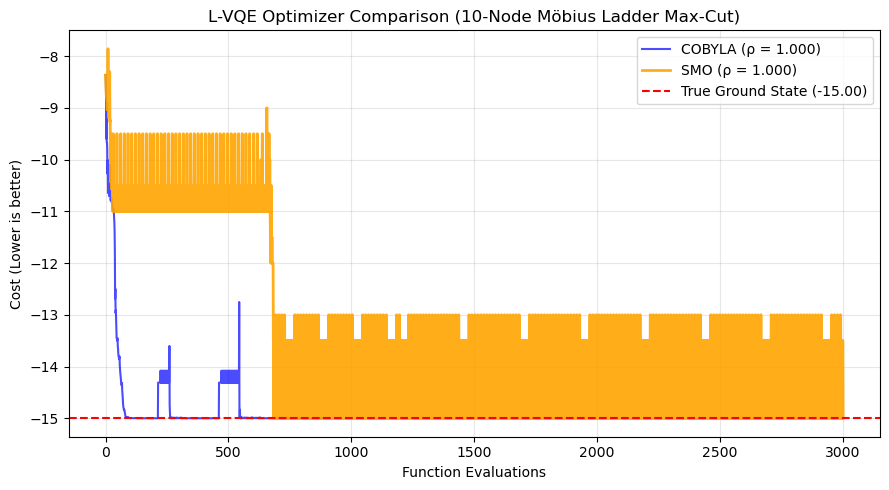

In [13]:
print("\n=== 3. OPTIMIZER TRAJECTORY COMPARISON (MAX-CUT) ===")
plt.figure(figsize=(9, 5))

# We plot the absolute cost (negative values) because we are directly minimizing the Max-Cut Hamiltonian
plt.plot(cobyla_res["cost_history"], label=f"COBYLA (ρ = {rho_cobyla:.3f})", color='blue', alpha=0.7)
plt.plot(smo_res["cost_history"], label=f"SMO (ρ = {rho_mc:.3f})", color='orange', alpha=0.9, linewidth=2)

# Plot the absolute classical ceiling (the lowest possible negative cost)
plt.axhline(true_maxcut_val, color="red", linestyle="--", linewidth=1.5, label=f"True Ground State ({true_maxcut_val:.2f})")

plt.title("L-VQE Optimizer Comparison (10-Node Möbius Ladder Max-Cut)")
plt.xlabel("Function Evaluations")
plt.ylabel("Cost (Lower is better)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
import time
import pandas as pd
import numpy as np
import networkx as nx

# Import from your engine
from l_vqe_engine import (
    build_maxcut_hamiltonian,
    best_known_maxcut_cost,
    simulate_one_lvqe,
    simulate_one_qaoa
)

print("=== 4. STARTING MAX-CUT BATCH ANALYSIS ===")

# --- Configuration ---
# We can push to 14 nodes because Max-Cut only uses 1 qubit per node
graph_sizes = [8, 10, 12, 14] 
n_seeds = 10
device = "lightning.qubit"  

# Budgets
lvqe_evals_per_layer = 600  
qaoa_evals = 3000           
qaoa_p_values = [1, 5, 10]  # Condensed p-values

results_data = []

for n_nodes in graph_sizes:
    print(f"\n--- Processing 3-Regular Graph: {n_nodes} Nodes ---")
    
    # Generate a random 3-regular graph (standard Max-Cut benchmark)
    G = nx.random_regular_graph(d=3, n=n_nodes, seed=42)
    n_q = n_nodes # 1 Qubit per node!
    
    print(f"Calculating true baseline for {n_nodes} nodes...")
    true_baseline = best_known_maxcut_cost(G)
    print('True Baseline:',true_baseline)
    H_mc = build_maxcut_hamiltonian(G)
    
    for seed in range(n_seeds):
        print(f"  Running Seed {seed+1}/{n_seeds}...")
        rng = np.random.default_rng(seed)
        
        # --- A. L-VQE (SMO) ---
        print('L-VQE(SMO):')
        t0 = time.time()
        res_smo = simulate_one_lvqe(
            n_q, H_mc, max_layers=2, shots=None, 
            max_iter_per_layer=lvqe_evals_per_layer, 
            rng=rng, device_name=device, optimizer="SMO"
        )
        rho_smo = res_smo['final_cost'] / true_baseline
        results_data.append({"Algorithm": "L-VQE (SMO)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_smo, "Time_s": time.time()-t0})

        # --- B. L-VQE (COBYLA) ---
        print('L-VQE(COBYLA):')
        t0 = time.time()
        res_cobyla = simulate_one_lvqe(
            n_q, H_mc, max_layers=2, shots=None, 
            max_iter_per_layer=lvqe_evals_per_layer, 
            rng=rng, device_name=device, optimizer="COBYLA"
        )
        rho_cobyla = res_cobyla['final_cost'] / true_baseline
        results_data.append({"Algorithm": "L-VQE (COBYLA)", "Nodes": n_nodes, "Seed": seed, "p_or_L": 2, "Rho": rho_cobyla, "Time_s": time.time()-t0})

        # --- C. QAOA ---
        print('QAOA:')
        for p in qaoa_p_values:
            print('p =',p)
            t0 = time.time()
            res_qaoa = simulate_one_qaoa(
                n_q, H_mc, p_steps=p, shots=None, 
                max_evals=qaoa_evals, rng=rng, device_name=device
            )
            rho_qaoa = res_qaoa['final_cost'] / true_baseline
            results_data.append({"Algorithm": "QAOA", "Nodes": n_nodes, "Seed": seed, "p_or_L": p, "Rho": rho_qaoa, "Time_s": time.time()-t0})

# --- Compile and Export ---
print("\n=== ANALYSIS COMPLETE. COMPILING DATA ===")
df_results = pd.DataFrame(results_data)
csv_filename = "data_maxcut_benchmark.csv"
df_results.to_csv(csv_filename, index=False)
print(f"Data successfully exported to '{csv_filename}'.")

=== 4. STARTING MAX-CUT BATCH ANALYSIS ===

--- Processing 3-Regular Graph: 8 Nodes ---
Calculating true baseline for 8 nodes...
True Baseline: -10.0
  Running Seed 1/10...
L-VQE(SMO):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.000000
L-VQE(COBYLA):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.000000
QAOA:
p = 1
p = 5
p = 10
  Running Seed 2/10...
L-VQE(SMO):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.000000
L-VQE(COBYLA):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.000000
QAOA:
p = 1
p = 5
p = 10
  Running Seed 3/10...
L-VQE(SMO):
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -10.000000
  Layer 2  (64 params) ... cost = -10.00

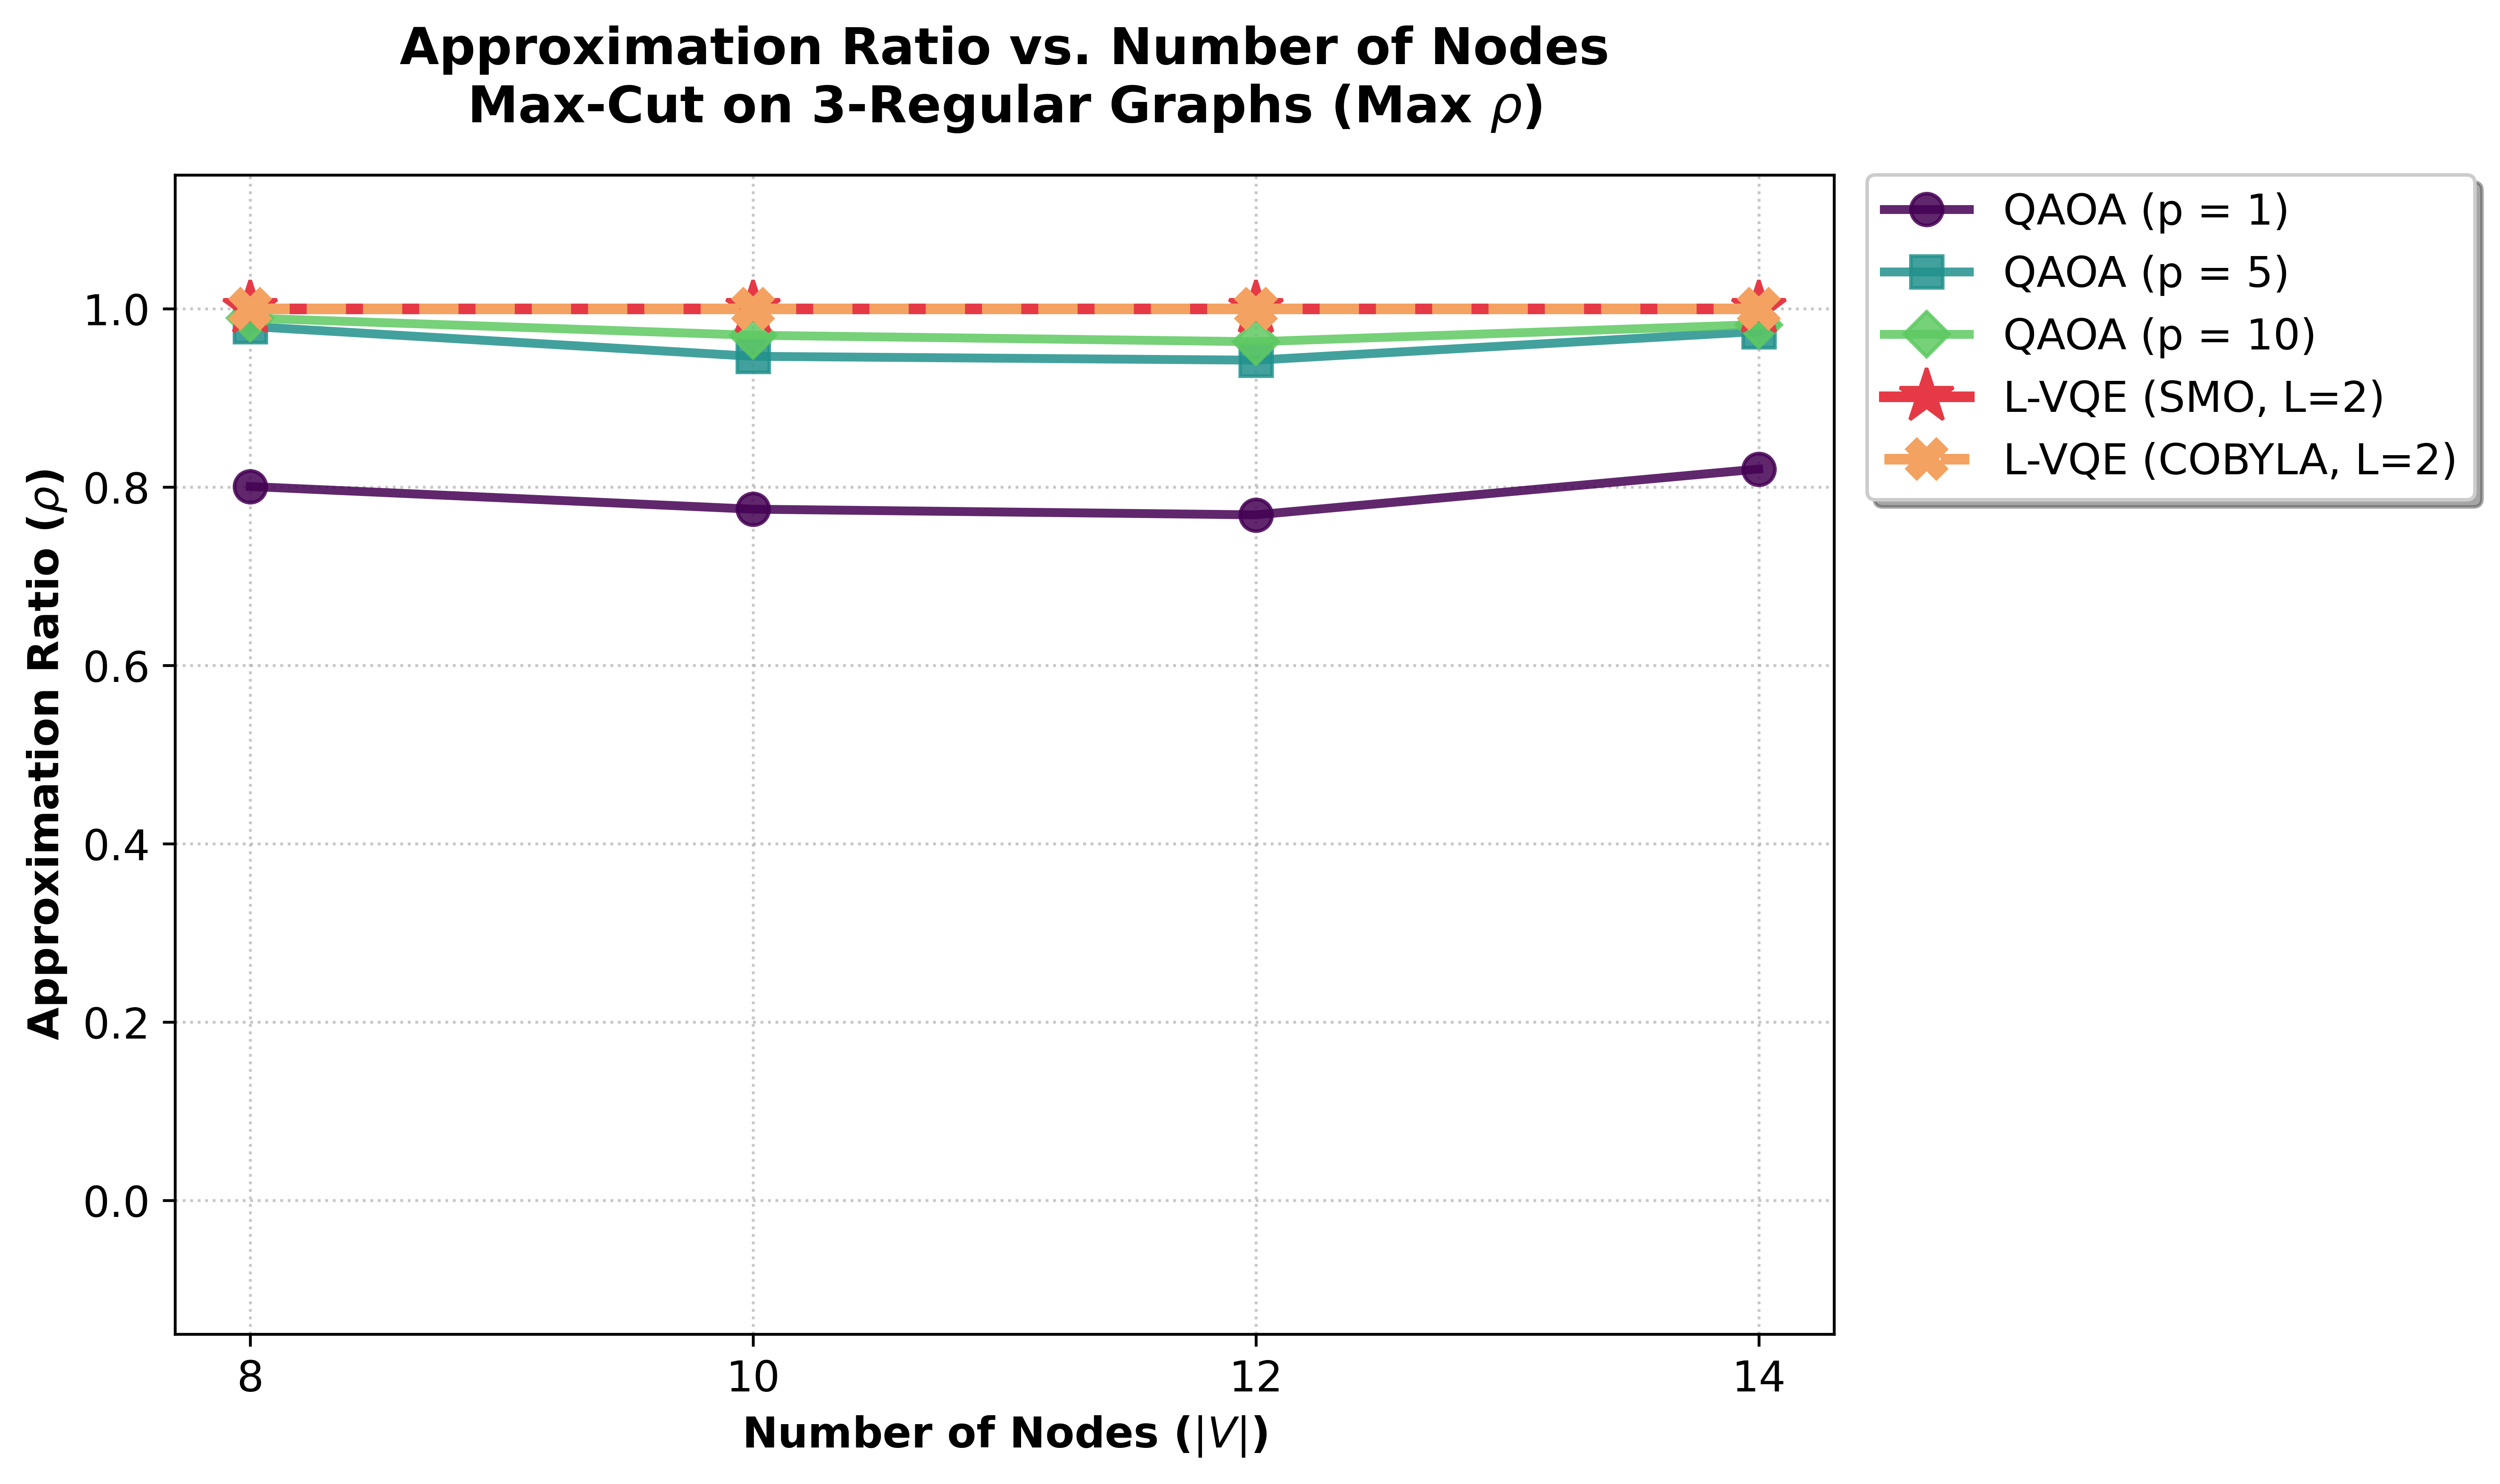

In [18]:
# Optional but highly recommended for Jupyter Notebooks:
# Tells the notebook to render output as high-res (Retina) PNGs
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#print("=== GENERATING MAX-CUT BENCHMARK PLOT (INLINE HIGH-RES) ===")

# 1. Load the exported Max-Cut batch data
csv_filename = "data_maxcut_benchmark.csv"
df = pd.read_csv(csv_filename)

# 2. Extract the BEST approximation ratio found across the 10 seeds
df_best = df.groupby(['Algorithm', 'Nodes', 'p_or_L'])['Rho'].max().reset_index()

# --- UPDATED DIMENSIONS & INLINE DPI ---
# Setting dpi=300 here forces the inline display to be ultra-crisp
plt.figure(figsize=(10, 6), dpi=300)
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# --- 3. Plot QAOA (Filtered for p=1, 5, 10) ---
qaoa_data = df_best[df_best['Algorithm'] == 'QAOA']
target_p_values = [1, 5, 10]
qaoa_filtered = qaoa_data[qaoa_data['p_or_L'].isin(target_p_values)]

# Hand-picked distinct colors & markers for clarity
qaoa_colors = {1: '#440154', 5: '#21918c', 10: '#5ec962'}  # Purple -> Teal -> Green
qaoa_markers = {1: 'o', 5: 's', 10: 'D'}

for p in target_p_values:
    subset = qaoa_filtered[qaoa_filtered['p_or_L'] == p]
    if not subset.empty:
        plt.plot(
            subset['Nodes'], subset['Rho'], 
            marker=qaoa_markers[p], markersize=9, 
            color=qaoa_colors[p], linewidth=2.5, alpha=0.85, 
            label=f'QAOA (p = {p})'
        )

# --- 4. Plot L-VQE (High contrast Warm colors to stand out) ---
lvqe_smo = df_best[df_best['Algorithm'] == 'L-VQE (SMO)']
plt.plot(
    lvqe_smo['Nodes'], lvqe_smo['Rho'], 
    marker='*', markersize=16, 
    color='#E63946', linewidth=3,  # Bold Crimson
    label='L-VQE (SMO, L=2)'
)

lvqe_cobyla = df_best[df_best['Algorithm'] == 'L-VQE (COBYLA)']
plt.plot(
    lvqe_cobyla['Nodes'], lvqe_cobyla['Rho'], 
    marker='X', markersize=11, 
    color='#F4A261', linewidth=3, linestyle='--',  # Vibrant Orange
    label='L-VQE (COBYLA, L=2)'
)

# --- 5. Formatting to strict academic style ---
plt.title("Approximation Ratio vs. Number of Nodes\nMax-Cut on 3-Regular Graphs (Max $\\rho$)", fontweight='bold', pad=15)
plt.xlabel("Number of Nodes ($|V|$)", fontweight='bold')
plt.ylabel("Approximation Ratio ($\\rho$)", fontweight='bold')

# Lock the ticks to the even node sizes used in the Max-Cut experiment
plt.xticks([8, 10, 12, 14])

# Dynamic Y-axis: Accommodate lower QAOA values if needed, capped at 1.05
y_min = min(0.3, df_best['Rho'].min() - 0.05)
plt.ylim(-0.15, 1.15) 

plt.grid(True, linestyle=':', alpha=0.7)


# Force the legend outside the plot area on the right side
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, framealpha=1.0, shadow=True)

plt.tight_layout()

# Render inline
plt.show()

In [19]:
# Optional but highly recommended for Jupyter Notebooks:
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('data_maxcut_benchmark.csv')

# Configure a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
axes = axes.flatten() # Flatten the 2x2 matrix to easily loop through it

# Max-Cut specific node sizes
nodes_list = [8, 10, 12, 14]
labels = ['QAOA\n(p=1)', 'QAOA\n(p=5)', 'QAOA\n(p=10)', 'L-VQE\n(SMO, L=2)', 'L-VQE\n(COBYLA, L=2)']

# Colors matched to your previous line graphs
colors = ['#440154', '#21918c', '#5ec962', '#E63946', '#F4A261'] 

for i, nodes in enumerate(nodes_list):
    df_n = df[df['Nodes'] == nodes]
    
    # Extract data arrays for each box
    q_1 = df_n[(df_n['Algorithm'] == 'QAOA') & (df_n['p_or_L'] == 1)]['Rho'].values
    q_5 = df_n[(df_n['Algorithm'] == 'QAOA') & (df_n['p_or_L'] == 5)]['Rho'].values
    q_10 = df_n[(df_n['Algorithm'] == 'QAOA') & (df_n['p_or_L'] == 10)]['Rho'].values
    l_smo = df_n[df_n['Algorithm'] == 'L-VQE (SMO)']['Rho'].values
    l_cob = df_n[df_n['Algorithm'] == 'L-VQE (COBYLA)']['Rho'].values
    
    # Handle empty arrays gracefully just in case
    data_to_plot = [
        q_1 if len(q_1) > 0 else [np.nan],
        q_5 if len(q_5) > 0 else [np.nan],
        q_10 if len(q_10) > 0 else [np.nan],
        l_smo if len(l_smo) > 0 else [np.nan],
        l_cob if len(l_cob) > 0 else [np.nan]
    ]
    
    # Create the boxplot for this specific node size
    box = axes[i].boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)
    
    # Apply the thematic colors
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        
    # Thicken the median line so it's readable on projectors
    for median in box['medians']:
        median.set(color='black', linewidth=2.5)
        
    # Format the subplot
    axes[i].set_title(f'{nodes}-Node 3-Regular Graph', fontweight='bold', fontsize=14)
    axes[i].set_ylim(-0.1, 1.1) # Unified Y-axis for direct comparison with Community Detection
    axes[i].grid(True, linestyle=':', alpha=0.7, axis='y')
    
    # Only label the outer left Y-axes to reduce clutter
    if i % 2 == 0:
        axes[i].set_ylabel('Approximation Ratio ($\\rho$)', fontweight='bold')

# Main layout adjustments
fig.suptitle("Variance & Robustness Across Network Sizes\nMax-Cut on 3-Regular Graphs", 
             fontweight='bold', fontsize=18, y=0.96)

# Leave room for the main title
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.show()

/tmp/ipykernel_896387/2707615323.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)
/tmp/ipykernel_896387/2707615323.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)
/tmp/ipykernel_896387/2707615323.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)
/tmp/ipykernel_896387/2707615323.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rename

In [6]:
# =============================================================
# SECTION: ENTANGLEMENT VS NO ENTANGLEMENT
# =============================================================

import pandas as pd
import time

print("=== ENTANGLEMENT VS NO ENTANGLEMENT (Max-Cut) ===")

n_seeds = 10
mc_ent_results = {"entanglement": [], "no_entanglement": []}
rows = []

for seed in range(n_seeds):
    print(f"\nSeed {seed+1}/{n_seeds}")

    rng = np.random.default_rng(seed)
    t0 = time.time()
    res_ent = simulate_one_lvqe(
        n_q=n_nodes,
        H=H_mc,
        max_layers=1,
        shots=None,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        no_entanglement=False
    )
    t_ent = time.time() - t0
    rho_ent = res_ent['final_cost'] / true_maxcut_val
    mc_ent_results["entanglement"].append(rho_ent)
    print(f"  With entanglement    → ρ = {rho_ent:.4f}  ({t_ent:.1f}s)")

    rows.append({
        "Algorithm": "L-VQE Entanglement",
        "Nodes":     n_nodes,
        "Seed":      seed,
        "p_or_L":    1,
        "Rho":       rho_ent,
        "Time_s":    t_ent,
    })

    rng = np.random.default_rng(seed)
    t0 = time.time()
    res_no = simulate_one_lvqe(
        n_q=n_nodes,
        H=H_mc,
        max_layers=1,
        shots=None,
        max_iter_per_layer=600,
        rng=rng,
        optimizer="SMO",
        no_entanglement=True
    )
    t_no = time.time() - t0
    rho_no = res_no['final_cost'] / true_maxcut_val
    mc_ent_results["no_entanglement"].append(rho_no)
    print(f"  Without entanglement → ρ = {rho_no:.4f}  ({t_no:.1f}s)")

    rows.append({
        "Algorithm": "L-VQE No Entanglement",
        "Nodes":     n_nodes,
        "Seed":      seed,
        "p_or_L":    1,
        "Rho":       rho_no,
        "Time_s":    t_no,
    })

df_ent_maxcut = pd.DataFrame(rows)
df_ent_maxcut.to_csv("data_entanglement_maxcut.csv", index=False)
print(f"\nSaved to data_entanglement_maxcut.csv")
print(df_ent_maxcut.to_string(index=False))

print("\n" + "="*55)
print("SUMMARY")
print("="*55)
for label, rhos in mc_ent_results.items():
    rhos_arr = np.array(rhos)
    print(f"\n{label}:")
    print(f"  best  = {rhos_arr.max():.4f}")
    print(f"  mean  = {rhos_arr.mean():.4f} ± {rhos_arr.std():.4f}")
    print(f"  >0.99 = {(rhos_arr > 0.99).mean()*100:.1f}%")
    print(f"  >0.95 = {(rhos_arr > 0.95).mean()*100:.1f}%")
    print(f"  >0.90 = {(rhos_arr > 0.90).mean()*100:.1f}%")

=== ENTANGLEMENT VS NO ENTANGLEMENT (Max-Cut) ===

Seed 1/10
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -15.000000
  With entanglement    → ρ = 1.0000  (5.2s)
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -15.000000
  Without entanglement → ρ = 1.0000  (4.8s)

Seed 2/10
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -15.000000
  With entanglement    → ρ = 1.0000  (4.9s)
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -11.000000
  Without entanglement → ρ = 0.7333  (4.9s)

Seed 3/10
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -15.000000
  With entanglement    → ρ = 1.0000  (4.8s)
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -11.000000
  Without entanglement → ρ = 0.7333  (4.9s)

Seed 4/10
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -15.000000
  With entan

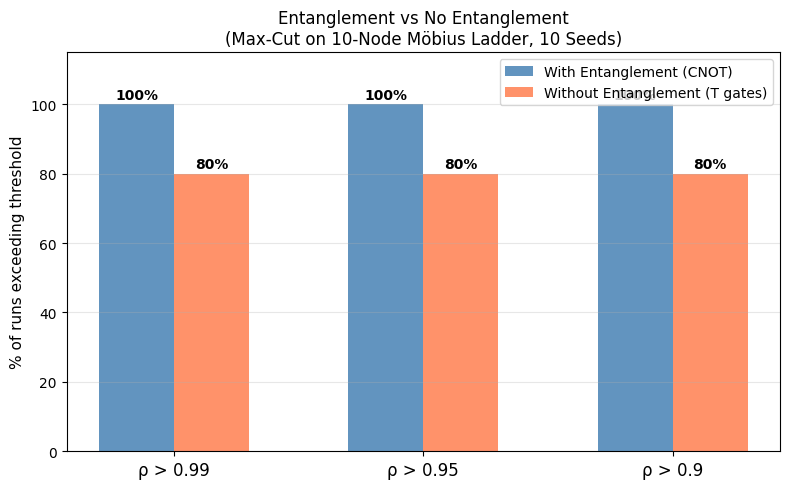

In [7]:
# =============================================================
# PLOT 1: Success rate by threshold (Max-Cut version of Table 10)
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ent_maxcut = pd.read_csv("data_entanglement_maxcut.csv")
mc_ent_arr = df_ent_maxcut[df_ent_maxcut["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
mc_no_arr  = df_ent_maxcut[df_ent_maxcut["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values

thresholds = [0.99, 0.95, 0.90]
x = np.arange(len(thresholds))
width = 0.3

mc_ent_pct = [(mc_ent_arr > t).mean() * 100 for t in thresholds]
mc_no_pct  = [(mc_no_arr  > t).mean() * 100 for t in thresholds]

plt.figure(figsize=(8, 5))
bars_ent = plt.bar(x - width/2, mc_ent_pct, width,
                   label="With Entanglement (CNOT)",
                   color="steelblue", alpha=0.85)
bars_no  = plt.bar(x + width/2, mc_no_pct, width,
                   label="Without Entanglement (T gates)",
                   color="coral", alpha=0.85)

for bar in bars_ent:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{bar.get_height():.0f}%",
             ha='center', fontsize=10, fontweight='bold')
for bar in bars_no:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{bar.get_height():.0f}%",
             ha='center', fontsize=10, fontweight='bold')

plt.xticks(x, [f"ρ > {t}" for t in thresholds], fontsize=12)
plt.ylabel("% of runs exceeding threshold", fontsize=11)
plt.title("Entanglement vs No Entanglement\n"
          "(Max-Cut on 10-Node Möbius Ladder, 10 Seeds)", fontsize=12)
plt.ylim(0, 115)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

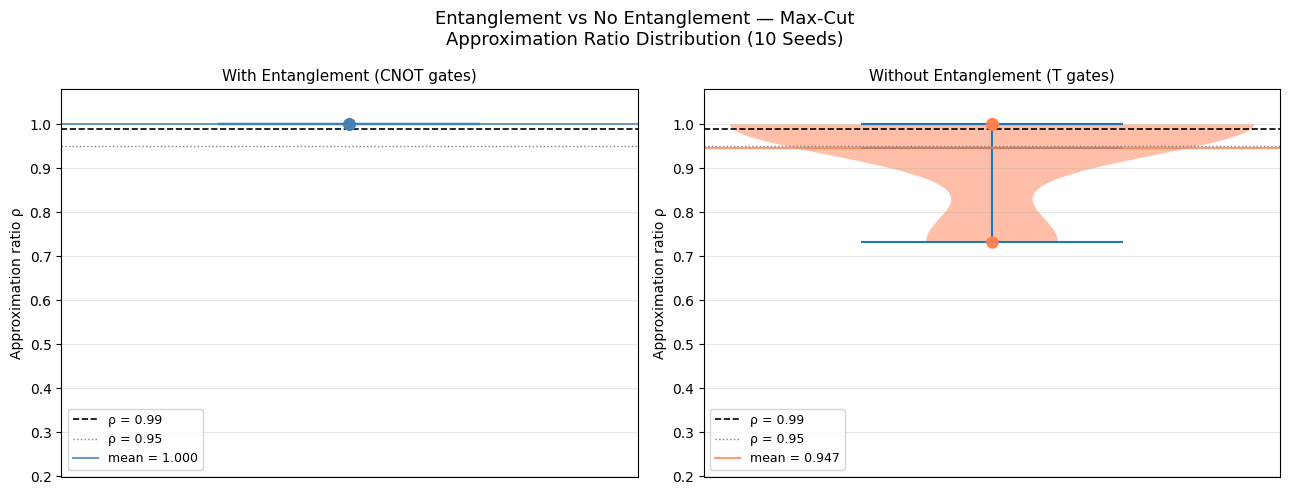

In [8]:
# =============================================================
# PLOT 2: Distribution violin plot (Max-Cut)
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ent_maxcut = pd.read_csv("data_entanglement_maxcut.csv")
mc_ent_arr = df_ent_maxcut[df_ent_maxcut["Algorithm"] == "L-VQE Entanglement"]["Rho"].values
mc_no_arr  = df_ent_maxcut[df_ent_maxcut["Algorithm"] == "L-VQE No Entanglement"]["Rho"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Entanglement vs No Entanglement — Max-Cut\n"
             "Approximation Ratio Distribution (10 Seeds)", fontsize=13)

for ax, rhos, color, title in zip(
    axes,
    [mc_ent_arr, mc_no_arr],
    ["steelblue", "coral"],
    ["With Entanglement (CNOT gates)",
     "Without Entanglement (T gates)"]
):
    vp = ax.violinplot([rhos], positions=[1],
                       showmeans=True, showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.5)

    ax.scatter([1]*len(rhos), rhos,
               color=color, alpha=0.8, s=60, zorder=3)

    ax.axhline(0.99, color="black", linestyle="--",
               linewidth=1.2, label="ρ = 0.99")
    ax.axhline(0.95, color="gray", linestyle=":",
               linewidth=1.0, label="ρ = 0.95")
    ax.axhline(rhos.mean(), color=color, linestyle="-",
               linewidth=1.5, alpha=0.8,
               label=f"mean = {rhos.mean():.3f}")

    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_ylabel("Approximation ratio ρ", fontsize=10)
    ax.set_ylim(0.2, 1.08)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()